# TrackFlow Sales Forecast

Simplified exploratory + modeling notebook (GeeksforGeeks-style steps) for TrackFlow monthly sales.

Schema and seasonality rules: `data/raw/CONTEXT-company.md`.


## Step-1: Import the Required libraries


In [19]:
import sys
from pathlib import Path
import importlib.util

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

_pkg = ROOT / 'data' / 'pipelines' / 'sales-forecast'

def _load(name, file_name):
    spec = importlib.util.spec_from_file_location(name, _pkg / file_name)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

split_mod = _load('sales_forecast_split', 'split.py')
metrics_mod = _load('sales_forecast_metrics', 'metrics.py')
temporal_split = split_mod.temporal_split
evaluate_regression = metrics_mod.evaluate_regression

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Step-2: Load the dataset

Monthly TrackFlow sales from `data/raw/trackflow_sales.csv` (US + ES, warehouses, service lines). Columns match `CONTEXT-company.md`.


In [20]:
sales_df = pd.read_csv(ROOT / 'data' / 'raw' / 'trackflow_sales.csv')
sales_df['date'] = pd.to_datetime(sales_df['date'])
sales_df.head(5)


,date,year,month,country,warehouse,service_line,orders,revenue_eur,returns_rate
0,2016-01-01,2016,1,US,Los_Angeles,fulfillment,2557,107383.17,0.2107
1,2016-01-01,2016,1,US,Los_Angeles,last_mile,1412,59318.16,0.2288
2,2016-01-01,2016,1,US,Los_Angeles,returns,862,25342.61,0.2483
3,2016-01-01,2016,1,ES,Zaragoza,fulfillment,1528,58058.62,0.2350
4,2016-01-01,2016,1,ES,Zaragoza,last_mile,894,33980.01,0.2115


## Step-3: Data Analysis On Sales Dataset

Familiarize with shape, dtypes, head/tail, and summary stats.


In [21]:
print(sales_df.head(5))


        date  year  month country    warehouse service_line  orders  \
0 2016-01-01  2016      1      US  Los_Angeles  fulfillment    2557   
1 2016-01-01  2016      1      US  Los_Angeles    last_mile    1412   
2 2016-01-01  2016      1      US  Los_Angeles      returns     862   
3 2016-01-01  2016      1      ES     Zaragoza  fulfillment    1528   
4 2016-01-01  2016      1      ES     Zaragoza    last_mile     894   

   revenue_eur  returns_rate  
0    107383.17        0.2107  
1     59318.16        0.2288  
2     25342.61        0.2483  
3     58058.62        0.2350  
4     33980.01        0.2115  


In [22]:
print(sales_df.tail(5))


          date  year  month country    warehouse service_line  orders  \
715 2025-12-01  2025     12      US  Los_Angeles    last_mile    4478   
716 2025-12-01  2025     12      US  Los_Angeles      returns    3188   
717 2025-12-01  2025     12      ES     Zaragoza  fulfillment    5330   
718 2025-12-01  2025     12      ES     Zaragoza    last_mile    2913   
719 2025-12-01  2025     12      ES     Zaragoza      returns    2220   

     revenue_eur  returns_rate  
715    188065.93        0.2360  
716     93724.85        0.2405  
717    202545.97        0.2044  
718    110705.39        0.1958  
719     59042.27        0.2462  


In [23]:
sales_df.duplicated().sum()


np.int64(0)

In [24]:
sales_df.shape


(720, 9)

In [25]:
sales_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          720 non-null    datetime64[ns]
 1   year          720 non-null    int64         
 2   month         720 non-null    int64         
 3   country       720 non-null    object        
 4   warehouse     720 non-null    object        
 5   service_line  720 non-null    object        
 6   orders        720 non-null    int64         
 7   revenue_eur   720 non-null    float64       
 8   returns_rate  720 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 50.8+ KB


In [26]:
sales_df.describe()


,date,year,month,orders,revenue_eur,returns_rate
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2020-12-15 18:00:00,2020.500000,6.500000,2330.827778,88728.363111,0.214537
min,2016-01-01 00:00:00,2016.000000,1.000000,620.000000,16491.990000,0.180100
25%,2018-06-23 12:00:00,2018.000000,3.750000,1391.250000,43223.425000,0.196100
50%,2020-12-16 12:00:00,2020.500000,6.500000,1931.500000,70286.550000,0.214300
75%,2023-06-08 12:00:00,2023.000000,9.250000,2928.500000,116659.117500,0.232950
max,2025-12-01 00:00:00,2025.000000,12.000000,8613.000000,361745.490000,0.250000
std,NaN,2.874278,3.454452,1325.603854,59860.566893,0.020725


## Step-4: Data Preparation

Handle nulls, scale numeric features where useful, then apply the **8-year train / 2-year test** temporal split (no shuffle).


In [27]:
sales_df.isnull().sum()


date            0
year            0
month           0
country         0
warehouse       0
service_line    0
orders          0
revenue_eur     0
returns_rate    0
dtype: int64

In [28]:
# Empty strings → NaN, then drop any incomplete rows before training
for col in sales_df.select_dtypes(include='object').columns:
    sales_df[col] = sales_df[col].replace('', np.nan)

sales_df = sales_df.dropna().reset_index(drop=True)
sales_df.isnull().sum()


date            0
year            0
month           0
country         0
warehouse       0
service_line    0
orders          0
revenue_eur     0
returns_rate    0
dtype: int64

In [29]:
# Aggregate to monthly total revenue for forecasting (preserve growth + seasonality)
monthly = (
    sales_df.groupby(['date', 'year', 'month'], as_index=False)
    .agg(revenue_eur=('revenue_eur', 'sum'), orders=('orders', 'sum'))
    .sort_values('date')
    .reset_index(drop=True)
)

# Lag / calendar features (bfill keeps all 10 years for the 8/2 split)
monthly['revenue_lag1'] = monthly['revenue_eur'].shift(1).bfill()
monthly['revenue_lag12'] = monthly['revenue_eur'].shift(12).bfill()
monthly['orders_lag1'] = monthly['orders'].shift(1).bfill()

train_df, test_df = temporal_split(monthly, train_years=8, test_years=2)
print('Train years:', sorted(train_df['year'].unique().tolist()))
print('Test years:', sorted(test_df['year'].unique().tolist()))
print('Train rows:', len(train_df), '| Test rows:', len(test_df))
assert train_df['date'].max() < test_df['date'].min()


Train years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Test years: [2024, 2025]
Train rows: 96 | Test rows: 24


In [30]:
feature_cols = ['month', 'orders_lag1', 'revenue_lag1', 'revenue_lag12']
target_col = 'revenue_eur'

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step-5: Exploratory Data Analysis

Quick look at trend and seasonality on the prepared monthly series.


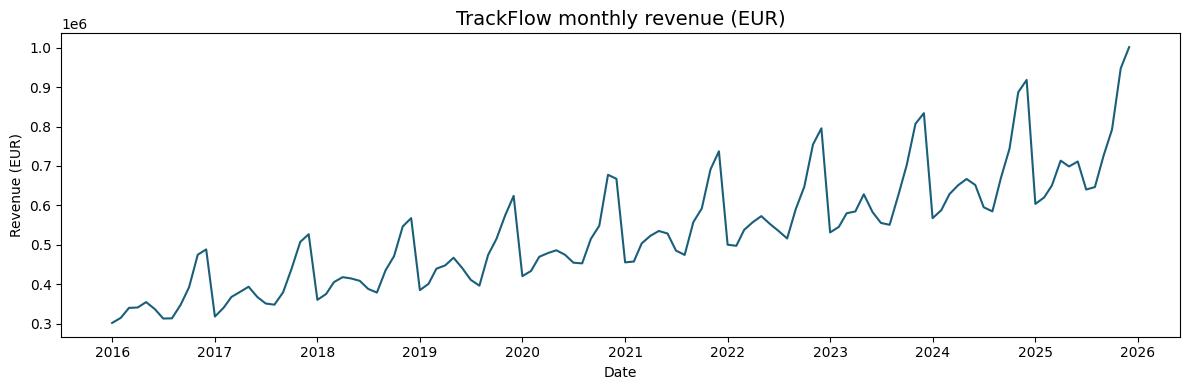

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(monthly['date'], monthly['revenue_eur'], color='#1a5f7a')
plt.title('TrackFlow monthly revenue (EUR)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Revenue (EUR)')
plt.tight_layout()
plt.show()


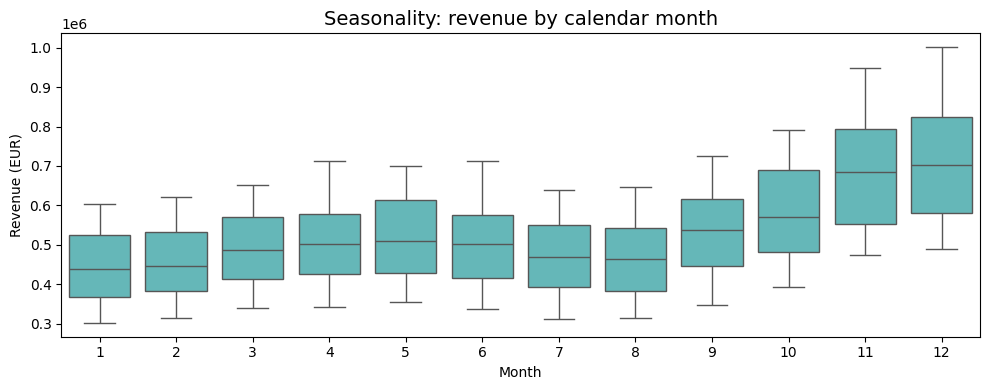

In [32]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='month', y='revenue_eur', data=monthly, color='#57c5c6')
plt.title('Seasonality: revenue by calendar month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (EUR)')
plt.tight_layout()
plt.show()


## Step-6: Model training

**Choice: Random Forest** (`sklearn.ensemble.RandomForestRegressor`) instead of XGBoost.

Reasons for this scaffold:
- Dataset is small (monthly series) — RF needs little tuning and trains quickly
- Native scikit-learn API (checklist allows RF or XGBoost via sklearn-friendly tooling)
- Tree ensemble gives per-tree predictions we can use for a variability band
- Easier to explain feature influence for an internal ops audience

`random_state=42` keeps the run reproducible.


In [33]:
# Random Forest: good default for small tabular series; fixed seed for reproducibility
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


## Step-7: Evaluation (test set only)

Metrics on the **held-out 2-year test set**:
- **MSE** — average squared error magnitude
- **PSI** — distribution drift vs a reference (train targets)
- **Gini** — ranking quality (order concordance), not just absolute error
- **K2** — D'Agostino–Pearson K² on residuals (residual shape / normality)

Low MSE alone is not enough: a model can match average level while drifting (PSI), mis-ranking periods (Gini), or leaving structured residual problems (K2).


In [34]:
scores = evaluate_regression(
    y_test.to_numpy(),
    y_pred,
    reference_for_psi=y_train.to_numpy(),
)
for name, value in scores.items():
    print(f'{name.upper():5s}: {value:,.4f}')


MSE  : 4,038,000,832.8842
PSI  : 10.6527
GINI : 0.9306
K2   : 17.1486


## Step-8: Predictions with variability range

Compare test actuals vs predictions and show a variability band from tree-level prediction spread (±1σ across trees).


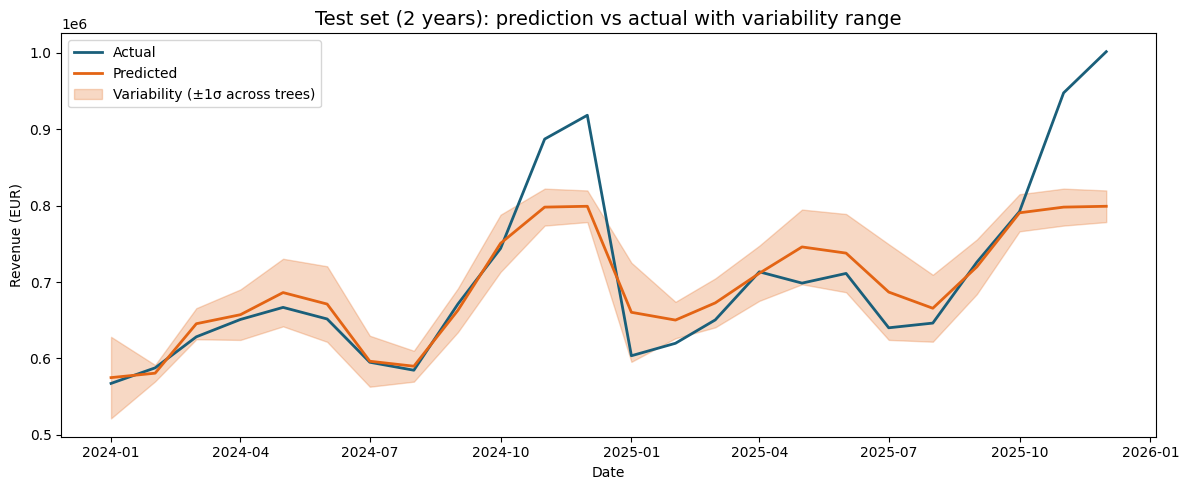

In [35]:
# Variability from individual trees in the forest
tree_preds = np.column_stack([
    est.predict(X_test_scaled) for est in model.estimators_
])
pred_mean = tree_preds.mean(axis=1)
pred_std = tree_preds.std(axis=1)

plot_df = test_df[['date', 'revenue_eur']].copy()
plot_df['y_pred'] = pred_mean
plot_df['y_low'] = pred_mean - pred_std
plot_df['y_high'] = pred_mean + pred_std

plt.figure(figsize=(12, 5))
plt.plot(plot_df['date'], plot_df['revenue_eur'], label='Actual', color='#1a5f7a', linewidth=2)
plt.plot(plot_df['date'], plot_df['y_pred'], label='Predicted', color='#e36414', linewidth=2)
plt.fill_between(
    plot_df['date'],
    plot_df['y_low'],
    plot_df['y_high'],
    color='#e36414',
    alpha=0.25,
    label='Variability (±1σ across trees)',
)
plt.title('Test set (2 years): prediction vs actual with variability range', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Revenue (EUR)')
plt.legend()
plt.tight_layout()
plt.show()
